In [79]:
import numpy as np
import scipy.stats as ss
import scipy as sp
import matplotlib.pyplot as plt 
import time
import math

# Task 1

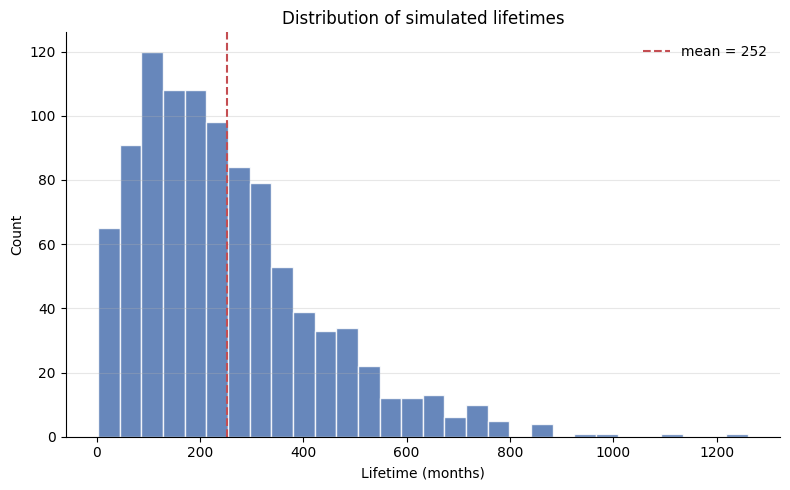

In [80]:
P = np.array([
    [0.9915, 0.005,  0.0025, 0.000, 0.001],
    [0.000,  0.986,  0.005,  0.004, 0.005],
    [0.000,  0.000,  0.992,  0.003, 0.005],
    [0.000,  0.000,  0.000,  0.991, 0.009],
    [0.000,  0.000,  0.000,  0.000, 1.000],])

rng  = np.random.default_rng(30)
N    = 1000
                

lifetimes = np.empty(N)
visited   = np.zeros((N, 5), bool)

for w in range(N):
    s = 0                          
    t = 0
    visited[w,s] = True
    while s != 4: # 4 = death
        s = rng.choice(5, p=P[s]) 
        t += 1
        visited[w,s] = True
    lifetimes[w] = t            

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(lifetimes, bins=30, color="#4C72B0", edgecolor="white", alpha=0.85)
ax.axvline(lifetimes.mean(), color="#C44E52", ls="--", lw=1.5,
           label=f"mean = {lifetimes.mean():.0f}")

ax.set_xlabel("Lifetime (months)")
ax.set_ylabel("Count")
ax.set_title("Distribution of simulated lifetimes")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

In [81]:
np.sum(visited[:,1])/N

np.float64(0.573)

# task 2 

In [82]:


N    = 1000
t  = 120

states = np.arange(0,5)

p_0 = np.array([1,0,0,0,0])

p_real = p_0@np.linalg.matrix_power(P,t)

p_real

array([0.35902627, 0.15895604, 0.1660869 , 0.06774149, 0.2481893 ])

In [83]:
rng  = np.random.default_rng(30)
lifetimes = np.empty(N)
last_state =np.zeros(N,dtype=int)
for w in range(N):
    s = 0                          
    t = 0
    while s != 4: # 4 = dø
        s = rng.choice(5, p=P[s]) 
        t += 1
        last_state[w] = s
        if t >= 120:
            break
    lifetimes[w] = t            

bincount = np.bincount(last_state, minlength=5)

p_estimate = bincount/N

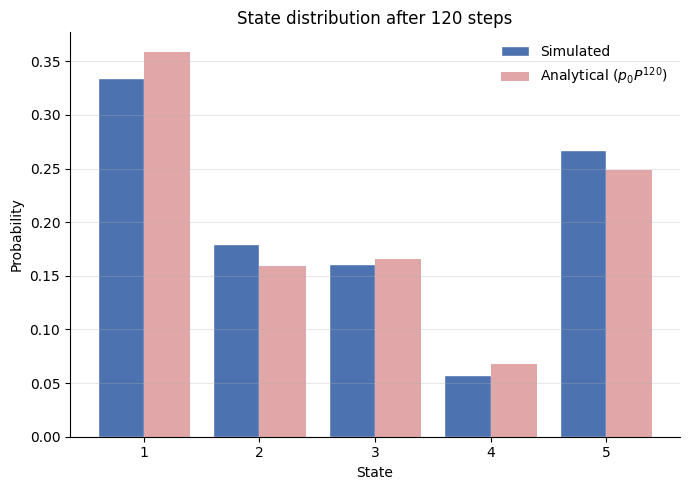

In [84]:
p_real = p_0 @ np.linalg.matrix_power(P, t)

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(states - 0.2+1, p_estimate, width=0.4, color="#4C72B0",
       edgecolor="white", label="Simulated")
ax.bar(states + 0.2+1, p_real, width=0.4, color="#C44E52",
       alpha=0.5, label="Analytical ($p_0 P^{120}$)")

ax.set_xlabel("State")
ax.set_ylabel("Probability")
ax.set_title("State distribution after 120 steps")
ax.set_xticks(states+1)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.3)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

In [85]:
ss.chisquare(bincount,p_real*N)

Power_divergenceResult(statistic=np.float64(7.51282134507163), pvalue=np.float64(0.11114525282277521))

# task 3

In [86]:
P_s = np.delete(P, -1, 0)  
P_s = np.delete(P_s, -1, 1) 

p_0 = np.array([1,0,0,0])
E =np.sum(p_0@np.linalg.inv(np.eye(4)-P_s))
E
p_s = P[:-1,-1]

dist = lambda t: p_0@np.linalg.matrix_power(P_s,t)@p_s


E,np.mean(bincount)

(np.float64(262.37161531279304), np.float64(200.0))

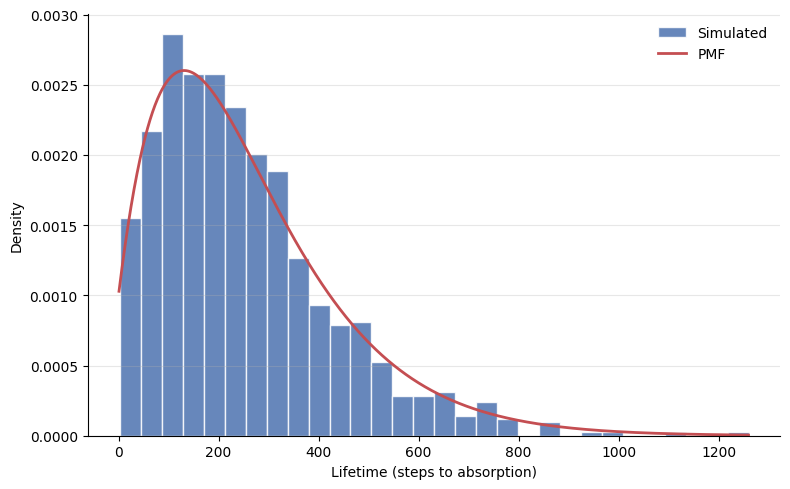

In [91]:
P = np.array([
    [0.9915, 0.005,  0.0025, 0.000, 0.001],
    [0.000,  0.986,  0.005,  0.004, 0.005],
    [0.000,  0.000,  0.992,  0.003, 0.005],
    [0.000,  0.000,  0.000,  0.991, 0.009],
    [0.000,  0.000,  0.000,  0.000, 1.000],])

rng  = np.random.default_rng(30)
N    = 1000
                

lifetimes = np.empty(N)
visited   = np.zeros((N, 5), bool)

for w in range(N):
    s = 0                          
    t = 0
    visited[w,s] = True
    while s != 4: # 4 = death
        s = rng.choice(5, p=P[s]) 
        t += 1
        visited[w,s] = True
    lifetimes[w] = t            


alpha = np.array([1, 0, 0, 0])

ts  = np.arange(1, int(lifetimes.max()) + 1)
pmf = np.array([dist(k) for k in ts])

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(lifetimes, bins=30, density=True, color="#4C72B0",
        edgecolor="white", alpha=0.85, label="Simulated")
ax.plot(ts, pmf, color="#C44E52", lw=2, label="PMF")

ax.set_xlabel("Lifetime (steps to absorption)")
ax.set_ylabel("Density")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

# task 4

In [36]:
rng    = np.random.default_rng(30)
target = 1000
lifetimes = []

while len(lifetimes) < target:
    s, t, recur12 = 0, 0, False
    while s != 4:                      
        s = rng.choice(5, p=P[s])
        t += 1
        if t <= 12 and s in (1, 2):    
            recur12 = True
    if recur12 and t > 12:             
        lifetimes.append(t)

np.mean(lifetimes)


np.float64(168.514)

In [38]:
np.var(lifetimes,ddof = 1),np.sqrt(np.var(lifetimes,ddof = 1))

(np.float64(19282.332136136138), np.float64(138.86083730172498))

# task 5

In [12]:
iterations = 100
rng  = np.random.default_rng(30)
fractions = np.zeros(iterations)
means = np.zeros_like(fractions)
for _ in range(iterations):
    N = 200
    lifetimes = np.empty(N)
    visited   = np.zeros((N, 5), bool)

    for w in range(N):
        s = 0                          
        t = 0
        visited[w,s] = True
        while s != 4: # 4 = death
            s = rng.choice(5, p=P[s]) 
            t += 1
            visited[w,s] = True
        lifetimes[w] = t
    means[_] = np.mean(lifetimes)        
    fractions[_]= np.mean(lifetimes < 350) 

In [13]:
np.mean(fractions),np.var(fractions,ddof= 1)

(np.float64(0.7372499999999998), np.float64(0.0010673611111111122))

In [14]:
X= fractions
Z = means
mu_Z = E
cov = np.cov(X, Z)            
c   = -cov[0,1] / cov[1,1]
Y   = X + c*(Z - mu_Z)

np.mean(Y),np.var(Y,ddof = 1)

(np.float64(0.7371295317090832), np.float64(0.0003515077233186783))